# 🍽️ Restaurant Transactions Analysis

## 📄 Project Overview

This project is part of a data analysis challenge aimed at exploring and extracting insights from a dataset of restaurant transactions. The dataset includes detailed information about sales, products, taxation, and customer behavior.

This challenge was designed to be open-ended to showcase analytical and technical skills in Python, data wrangling, visualization, and reporting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

%matplotlib inline

In [15]:
#📂 Caricamento CSV
df = pd.read_csv("/home/giovanni01/Scrivania/restaurant-data-challenge/restaurant-analitycs/data/transactions.csv")

print("Dimensioni del dataset:", df.shape)
df.head(20)

Dimensioni del dataset: (664633, 15)


,Date,Transaction ID,Table ID,# guests,Category and product ID,Product category,Product ID,Amount,Price,Taxation type,Tax rate %,Tax,Net minus tax,At the table Takeaway/Delivery,Lunch/Dinner
0,2021-06-01 09:34:59,17085,NO TAVOLO,0,ET00345,ET00345,ET00345,1.5,31.5,2,10,3.15,28.35,Asporto/Delivery,Pranzo
1,2021-06-01 12:16:00,4405,ASP2,0,PIZZE-00071,PIZZE,71,1.0,8.0,2,10,0.80,7.20,Asporto/Delivery,Pranzo
2,2021-06-01 12:16:00,4405,ASP2,0,IMPAST PIZZA-0003,IMPASTPIZZA,3,1.0,0.0,2,10,0.00,0.00,Asporto/Delivery,Pranzo
3,2021-06-01 12:16:00,4405,ASP2,0,BEVERAGE-00111,BEVERAGE,111,1.0,1.0,2,10,0.10,0.90,Asporto/Delivery,Pranzo
4,2021-06-01 12:16:00,4405,ASP2,0,BEVERAGE-00004,BEVERAGE,4,1.0,3.0,2,10,0.30,2.70,Asporto/Delivery,Pranzo
5,2021-06-01 12:16:00,4405,ASP2,0,COPERTO - 00001,COPERTO,1,1.0,2.5,2,10,0.25,2.25,Asporto/Delivery,Pranzo
6,2021-06-01 12:16:00,4405,ASP2,0,PIZZE-00011,PIZZE,11,1.0,9.5,2,10,0.95,8.55,Asporto/Delivery,Pranzo
7,2021-06-01 12:16:00,4405,ASP2,0,IMPAST PIZZA-0003,IMPASTPIZZA,3,1.0,0.0,2,10,0.00,0.00,Asporto/Delivery,Pranzo
8,2021-06-01 12:16:00,4405,ASP2,0,CAFFETTERIA-00001,CAFFETTERIA,1,1.0,2.0,2,10,0.20,1.80,Asporto/Delivery,Pranzo
9,2021-06-01 12:16:00,4406,ARA7,1,PIZZE-00071,PIZZE,71,1.0,8.0,2,10,0.80,7.20,Coperto,Pranzo


In [3]:
# Conversione data
df['Date'] = pd.to_datetime(df['Date'])

# Rinomina colonne
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Drop duplicati e copia esplicita per evitare warning
print(f"Righe prima: {len(df)}")
df = df.drop_duplicates().copy()
print(f"Righe dopo drop duplicates: {len(df)}")

num_cols = ['Price', 'Tax', 'Tax_rate_%', 'Net_minus_tax', 'Amount', '#_guests']
for col in num_cols:
    df.loc[:, col] = pd.to_numeric(df[col], errors='coerce')

# Controllo valori nulli
print("Valori nulli:\n", df.isnull().sum())

Righe prima: 664633
Righe dopo drop duplicates: 539413
Valori nulli:
 Date                              0
Transaction_ID                    0
Table_ID                          0
#_guests                          0
Category_and_product_ID           0
Product_category                  0
Product_ID                        0
Amount                            0
Price                             0
Taxation_type                     0
Tax_rate_%                        0
Tax                               0
Net_minus_tax                     0
At_the_table_Takeaway/Delivery    0
Lunch/Dinner                      0
dtype: int64


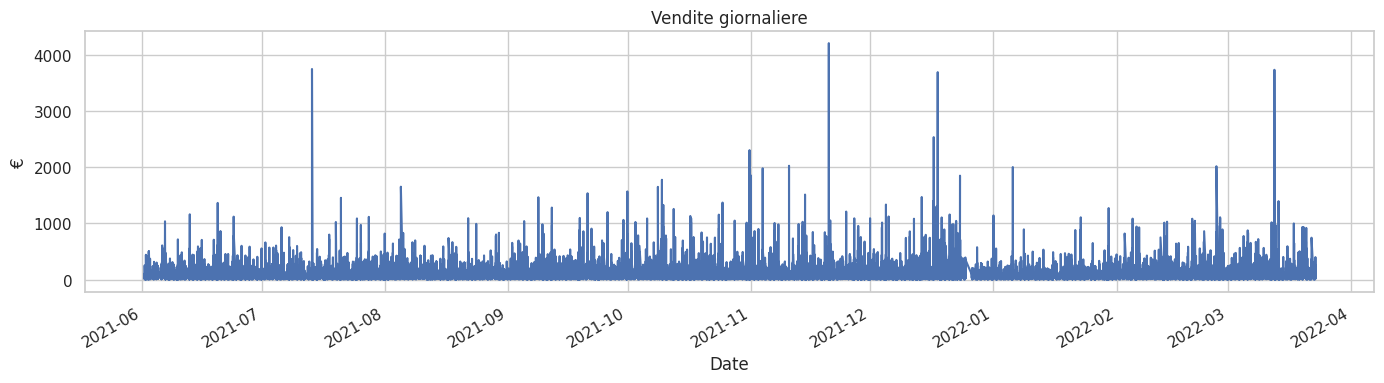

In [4]:
#1. 📈 Andamento giornaliero delle vendite

vendite_giornaliere = df.groupby('Date')['Price'].sum()
vendite_giornaliere.plot(figsize=(14,4), title='Vendite giornaliere', ylabel='€')
plt.grid(True)
plt.tight_layout()
plt.show()

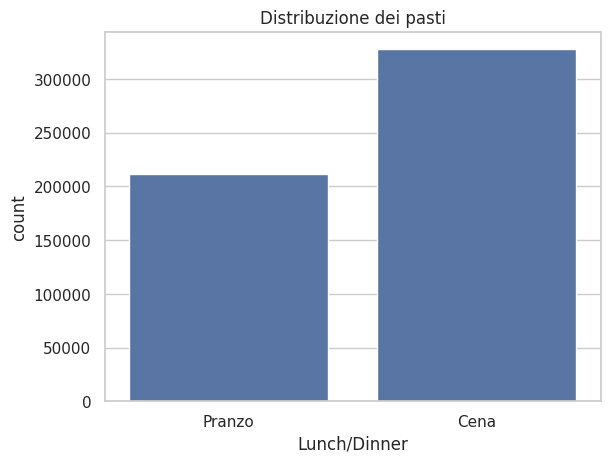

In [5]:
#2. 🍽️ Distribuzione Lunch vs Dinner

sns.countplot(data=df, x='Lunch/Dinner')
plt.title("Distribuzione dei pasti")
plt.show()

In [6]:
#3. 🧾 Scontrino medio per transazione

scontrino_medio = df.groupby('Transaction_ID')['Price'].sum().mean()
print("💳 Scontrino medio: €", round(scontrino_medio, 2))

💳 Scontrino medio: € 73.56


In [7]:
#4. 👨‍👩‍👧‍👦 Numero medio di ospiti per transazione

ospiti_medi = df.groupby('Transaction_ID')['#_guests'].max().mean()
print("👥 Ospiti medi per transazione:", round(ospiti_medi, 2))

👥 Ospiti medi per transazione: 2.06


/tmp/ipykernel_702341/838677097.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


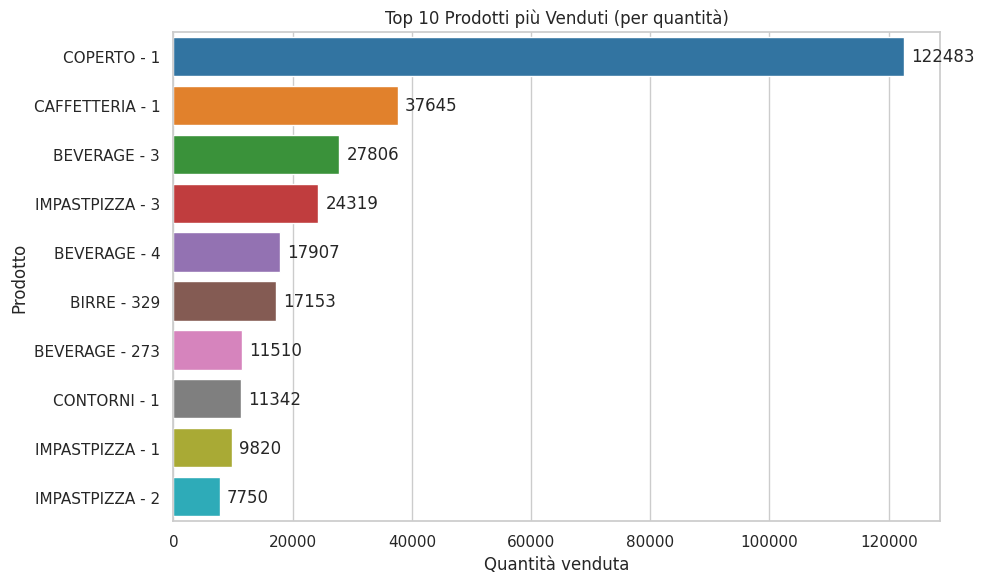

In [8]:
#5. 🧺 Top 10 prodotti più venduti per quantità

# Etichetta per prodotto
df['Product_Label'] = df['Product_category'] + " - " + df['Product_ID'].astype(str)

# Calcolo top 10 quantità
top_prodotti = df.groupby('Product_Label')['Amount'].sum().sort_values(ascending=False).head(10).reset_index()

# Grafico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_prodotti,
    x='Amount',
    y='Product_Label',
    palette=sns.color_palette("tab10", n_colors=10)
)
plt.title("Top 10 Prodotti più Venduti (per quantità)")
plt.xlabel("Quantità venduta")
plt.ylabel("Prodotto")

for index, row in top_prodotti.iterrows():
    plt.text(row['Amount'] + max(top_prodotti['Amount'])*0.01, index, 
             int(row['Amount']), va='center')

plt.tight_layout()
plt.show()

/tmp/ipykernel_702341/1315493899.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


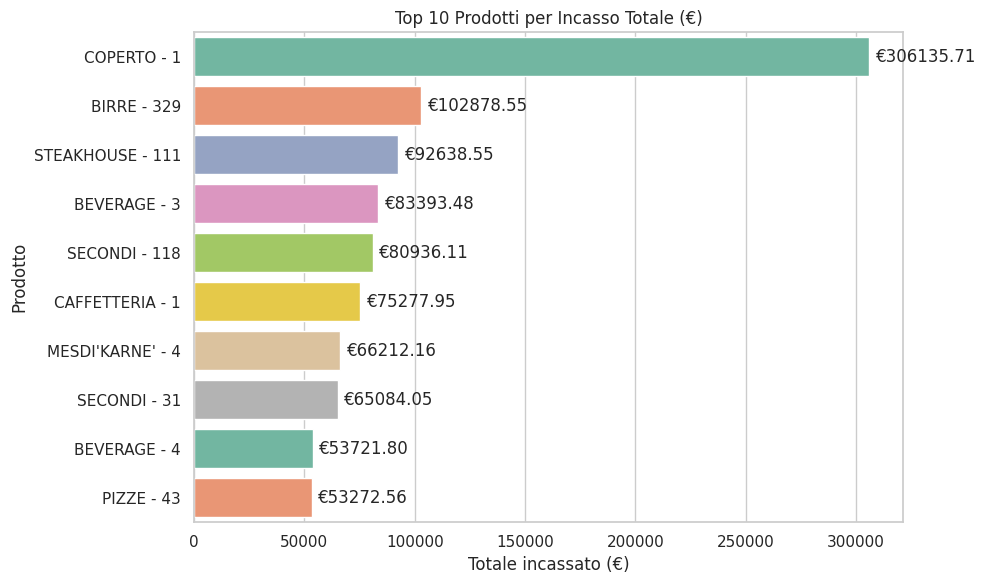

In [9]:
#💰 6. Top 10 Prodotti per Incasso Totale 

# Calcolo top 10 incasso
top_valore = df.groupby('Product_Label')['Price'].sum().sort_values(ascending=False).head(10).reset_index()

# Grafico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_valore,
    x='Price',
    y='Product_Label',
    palette=sns.color_palette("Set2", n_colors=10)
)
plt.title("Top 10 Prodotti per Incasso Totale (€)")
plt.xlabel("Totale incassato (€)")
plt.ylabel("Prodotto")

for index, row in top_valore.iterrows():
    plt.text(row['Price'] + max(top_valore['Price'])*0.01, index,
             f"€{row['Price']:.2f}", va='center')

plt.tight_layout()
plt.show()

/tmp/ipykernel_689299/1201742756.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribuzione.index, y=distribuzione.values, palette="mako")
/tmp/ipykernel_689299/1201742756.py:25: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/giovanni01/Scrivania/restaurant-data-challenge/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


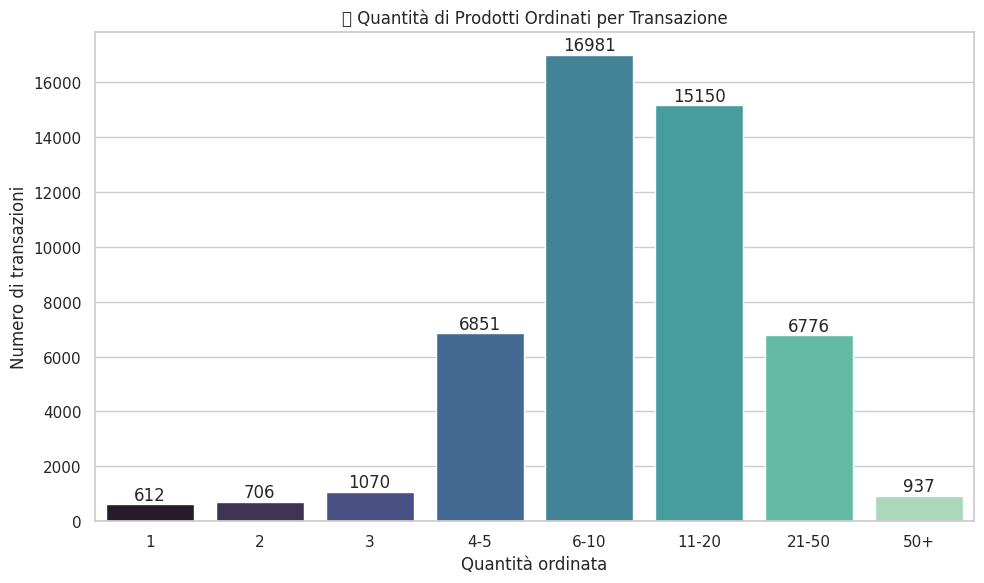

🔢 Distribuzione quantità per transazione:

Amount
1          612
2          706
3         1070
4-5       6851
6-10     16981
11-20    15150
21-50     6776
50+        937
Name: count, dtype: int64


In [13]:
# 7. 🧮 Distribuzione del numero di prodotti per transazione

# Raggruppamento prodotti per ogni transazione
prod_per_trans = df.groupby('Transaction_ID')['Amount'].sum()

# Classi di quantità ordinate
bins = [0, 1, 2, 3, 5, 10, 20, 50, prod_per_trans.max()]
labels = ['1', '2', '3', '4-5', '6-10', '11-20', '21-50', '50+']
prod_per_trans_binned = pd.cut(prod_per_trans, bins=bins, labels=labels, right=True)

# Transazioni per fascia
distribuzione = prod_per_trans_binned.value_counts().sort_index()

# Grafico
plt.figure(figsize=(10, 6))
sns.barplot(x=distribuzione.index, y=distribuzione.values, palette="mako")
plt.title("📦 Quantità di Prodotti Ordinati per Transazione")
plt.xlabel("Quantità ordinata")
plt.ylabel("Numero di transazioni")

for i, val in enumerate(distribuzione.values):
    plt.text(i, val + max(distribuzione.values)*0.01, str(val), ha='center')

plt.tight_layout()
plt.show()

print("🔢 Distribuzione quantità per transazione:\n")
print(distribuzione)

/tmp/ipykernel_702341/1718658086.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendite_weekday.index, y=vendite_weekday.values, palette="rocket")
/tmp/ipykernel_702341/1718658086.py:21: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/giovanni01/Scrivania/restaurant-data-challenge/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


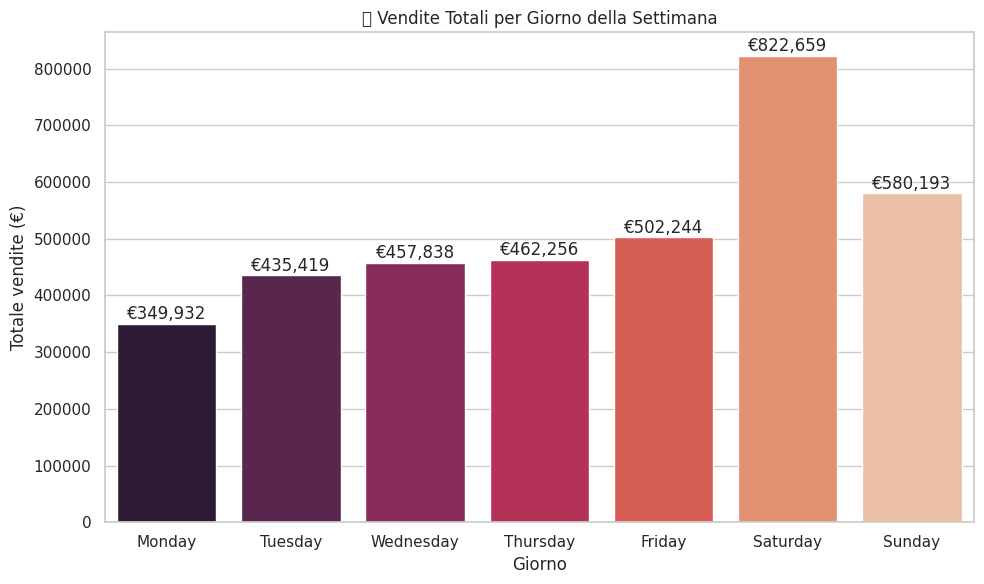

💡 Vendite totali per giorno della settimana:

Weekday
Monday       €349,932.35
Tuesday      €435,418.72
Wednesday    €457,837.52
Thursday     €462,256.24
Friday       €502,244.15
Saturday     €822,659.05
Sunday       €580,192.88
Name: Price, dtype: object


In [10]:
#8. 📆 Distribuzione vendite per giorno della settimana

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Weekday'] = df['Date'].dt.day_name()

# Vendite per giorno della settimana
vendite_weekday = df.groupby('Weekday')['Price'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

# Grafico
plt.figure(figsize=(10, 6))
sns.barplot(x=vendite_weekday.index, y=vendite_weekday.values, palette="rocket")
plt.title("📆 Vendite Totali per Giorno della Settimana")
plt.xlabel("Giorno")
plt.ylabel("Totale vendite (€)")

for i, val in enumerate(vendite_weekday.values):
    plt.text(i, val + max(vendite_weekday.values)*0.01, f"€{val:,.0f}", ha='center')

plt.tight_layout()
plt.show()

print("💡 Vendite totali per giorno della settimana:\n")
print(vendite_weekday.apply(lambda x: f"€{x:,.2f}"))

In [11]:
#9 ⚙️ Clustering dei clienti

df['Date'] = pd.to_datetime(df['Date'])

# Dataset clienti aggregato
clienti = df.groupby('Transaction_ID').agg({
    'Price': 'sum',                         
    '#_guests': 'mean',                    
    'Amount': 'sum',                        
    'Lunch/Dinner': lambda x: (x == 'Cena').mean(),  
    'At_the_table_Takeaway/Delivery': lambda x: (x == 'Asporto/Delivery').mean(),
    'Product_category': pd.Series.nunique   
}).reset_index()


clienti.columns = ['Transaction_ID', 'Totale_speso', 'Num_ospiti', 'Totale_prodotti', 
                   'Percentuale_cena', 'Percentuale_asporto', 'Diversità_prodotti']

clienti.head()

,Transaction_ID,Totale_speso,Num_ospiti,Totale_prodotti,Percentuale_cena,Percentuale_asporto,Diversità_prodotti
0,1,155.00,1.187500,37.00,0.812500,0.40625,10
1,10,122.00,0.000000,18.00,1.000000,1.00000,5
2,100,116.00,2.600000,20.00,0.200000,0.00000,11
3,1000,125.00,1.631579,21.00,0.368421,0.00000,12
4,10000,55.95,1.000000,11.39,0.000000,0.00000,11


In [12]:
# Clustering con KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

features = clienti.drop('Transaction_ID', axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
clienti['Cluster'] = kmeans.fit_predict(scaled_features)

# Riduzione dimensionale per visualizzazione
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
clienti['PCA1'] = pca_features[:,0]
clienti['PCA2'] = pca_features[:,1]

/tmp/ipykernel_702341/2194858364.py:8: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/giovanni01/Scrivania/restaurant-data-challenge/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


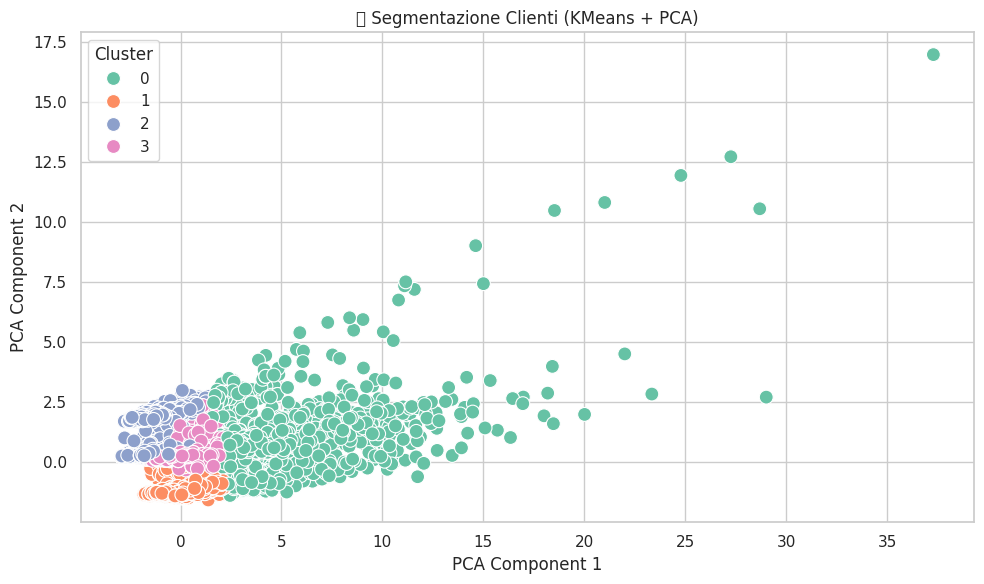

In [13]:
# Visualizzazione dei Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clienti, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=100)
plt.title("🎯 Segmentazione Clienti (KMeans + PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [14]:
# Medie per cluster
profilo_cluster = clienti.groupby('Cluster')[clienti.select_dtypes(include='number').columns].mean().round(2)
print("📊 Profili cluster:\n")
print(profilo_cluster)

📊 Profili cluster:

         Totale_speso  Num_ospiti  Totale_prodotti  Percentuale_cena  \
Cluster                                                                
0              260.12        6.03            43.54              0.72   
1               56.36        1.95            10.65              0.00   
2               35.67        0.00             7.27              0.63   
3               67.73        2.30            12.51              0.99   

         Percentuale_asporto  Diversità_prodotti  Cluster  PCA1  PCA2  
Cluster                                                                
0                       0.04               11.78      0.0  4.12  0.59  
1                       0.00                6.68      1.0 -0.20 -1.21  
2                       1.00                4.34      2.0 -1.85  1.29  
3                       0.01                7.31      3.0  0.26  0.27  


# 📊 Conclusioni e Insight

## 🔍 Andamento Vendite

- Le **vendite giornaliere** mostrano flussi costanti con picchi marcati durante i weekend.
- Il **sabato** è il giorno con il maggiore incasso totale, seguito dalla **domenica**, a conferma della centralità dei servizi del fine settimana.

## 🕐 Lunch vs Dinner

- La fascia **serale (Dinner)** rappresenta la quota maggiore di vendite totali.
- Alcuni cluster di clienti sono fortemente associati alla cena, con una spesa media più alta rispetto al pranzo.

## 🍕 Prodotti e Categorie

- I **prodotti più venduti** sono in prevalenza della categoria **PIZZE**.
- I **prodotti con il maggiore incasso complessivo** appartengono anch’essi a PIZZE, seguiti da BEVERAGE.
- Analisi di categoria ha evidenziato una **forte concentrazione delle vendite** in pochi prodotti top.

## 🧾 Scontrino Medio

- Lo **scontrino medio per transazione** è di circa **€ 73,56** 
- Transazioni con più ospiti generano uno scontrino maggiore, ma meno frequente.

## 🚚 Tipologia Consumo

- La maggior parte delle vendite avviene **al tavolo**.
- Tuttavia, un segmento rilevante (Cluster 2) è composto **esclusivamente da clienti takeaway/delivery**, con comportamento distinto e mirato.

## 📦 Segmentazione Clienti (KMeans)

Attraverso l’analisi dei pattern d’acquisto è stata effettuata una **segmentazione della clientela** tramite KMeans (supportata da PCA):

| Cluster | Totale Speso (€) | N. Ospiti | Totale Prodotti | % Cena | % Asporto | Diversità Prodotti |
|---------|------------------|-----------|------------------|--------|-----------|---------------------|
|   0     |      260.12      |   6.03    |      43.54       |  0.72  |   0.04    |        11.78        |
|   1     |       56.36      |   1.95    |      10.65       |  0.00  |   0.00    |         6.68        |
|   2     |       35.67      |   0.00    |       7.27       |  0.63  |   1.00    |         4.34        |
|   3     |       67.73      |   2.30    |      12.51       |  0.99  |   0.01    |         7.31        |

- **Cluster 0**: Clienti ad alta spesa e alta varietà, spesso in gruppo, tipicamente a cena.
- **Cluster 1**: Clienti con basso consumo, visita occasionale.
- **Cluster 2**: Completamente orientati all’asporto, bassa spesa e varietà.
- **Cluster 3**: Frequentano la cena con regolarità, spesa medio-bassa ma stabile.

## 🧠 Conclusione

L’analisi ha permesso di:

- Identificare pattern ricorrenti di consumo e orari
- Evidenziare i prodotti core su cui concentrare l’offerta
- Segmentare la clientela per strategie mirate